In [7]:
from src.evaluation import compute_max_swaps_count, compute_structural_depth, compute_quantum_depth
import math
import numpy as np

### Plotting Function

In [8]:
import os
import matplotlib.pyplot as plt
import json
import numpy as np

def plot_routing_comparison(nb_qubits, nb_loop_iterations, use_log_scale=False):
    """
    Plot comparison of routing methods for quantum circuits.
    
    Parameters:
    -----------
    nb_qubits : int
        Number of qubits (e.g., 16)
    nb_loop_iterations : int
        Number of loop iterations for metrics computation
    use_log_scale : bool, optional
        Whether to use logarithmic scale (default: False)
    """
    # Load files from results directories
    results_dir = f'results/{nb_qubits}qbt'
    sabre_dir = f'results_sabre/{nb_qubits}qbt'
    
    files = []
    for root, dirs, filenames in os.walk(results_dir):
        for f in filenames:
            if f.endswith('.json'):
                files.append(os.path.join(root, f))

    sabre_files = []
    for root, dirs, filenames in os.walk(sabre_dir):
        for f in filenames:
            if f.endswith('.json'):
                sabre_files.append(os.path.join(root, f))

    max_swaps = []
    quantum_depths = []
    file_names = []

    max_swaps_sabre = []
    quantum_depths_sabre = []
    file_names_sabre = []

    # Process each file
    for file in files:
        with open(file, 'r') as fp:
            trace = json.load(fp)
        
        swaps = compute_max_swaps_count(trace, loop_iterations=nb_loop_iterations)
        if use_log_scale:
            swaps = 0 if swaps == 0 else round(np.log2(swaps))
        depth = compute_quantum_depth(trace, loop_iterations=nb_loop_iterations)
        if use_log_scale:
            depth = 0 if depth == 0 else round(np.log2(depth))

        max_swaps.append(swaps)
        quantum_depths.append(depth)
        file_names.append(file)

    for file in sabre_files:
        with open(file, 'r') as fp:
            trace = json.load(fp)
        
        swaps = compute_max_swaps_count(trace, loop_iterations=nb_loop_iterations)
        if use_log_scale:
            swaps = 0 if swaps == 0 else round(np.log2(swaps))
        depth = compute_quantum_depth(trace, loop_iterations=nb_loop_iterations)
        if use_log_scale:
            depth = 0 if depth == 0 else round(np.log2(depth))

        max_swaps_sabre.append(swaps)
        quantum_depths_sabre.append(depth)
        file_names_sabre.append(file)

    # Group files by their parent directory (leaf-depth level)
    leaf_depth_groups = {}
    leaf_depth_groups_sabre = {}
    
    for i, file in enumerate(file_names):
        parts = file.split(os.sep)
        for part in parts:
            if 'leaf-depth-' in part:
                leaf_depth = int(part.split('leaf-depth-')[-1])
                if leaf_depth not in leaf_depth_groups:
                    leaf_depth_groups[leaf_depth] = {'swaps': [], 'depths': []}
                leaf_depth_groups[leaf_depth]['swaps'].append(max_swaps[i])
                leaf_depth_groups[leaf_depth]['depths'].append(quantum_depths[i])
                break
                
    for i, file in enumerate(file_names_sabre):
        parts = file.split(os.sep)
        for part in parts:
            if 'leaf-depth-' in part:
                leaf_depth = int(part.split('leaf-depth-')[-1])
                if leaf_depth not in leaf_depth_groups_sabre:
                    leaf_depth_groups_sabre[leaf_depth] = {'swaps': [], 'depths': []}
                leaf_depth_groups_sabre[leaf_depth]['swaps'].append(max_swaps_sabre[i])
                leaf_depth_groups_sabre[leaf_depth]['depths'].append(quantum_depths_sabre[i])
                break

    # Calculate averages
    leaf_depths_sorted = sorted(leaf_depth_groups.keys())
    avg_swaps = [np.mean(leaf_depth_groups[ld]['swaps']) for ld in leaf_depths_sorted]
    avg_depths = [np.mean(leaf_depth_groups[ld]['depths']) for ld in leaf_depths_sorted]

    leaf_depths_sorted_sabre = sorted(leaf_depth_groups_sabre.keys())
    avg_swaps_sabre = [np.mean(leaf_depth_groups_sabre[ld]['swaps']) for ld in leaf_depths_sorted_sabre]
    avg_depths_sabre = [np.mean(leaf_depth_groups_sabre[ld]['depths']) for ld in leaf_depths_sorted_sabre]
    
    # Plot the results
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    ax1.plot(leaf_depths_sorted, avg_swaps, marker='o', label='Our Method')
    ax1.plot(leaf_depths_sorted_sabre, avg_swaps_sabre, marker='s', color='orange', label='Sabre')
    ax1.set_xlabel('Circuit Complexity')
    ax1.set_ylabel('Max Swaps Count')
    ax1.set_title('Max Swaps Count vs Circuit Complexity')
    ax1.legend()
    ax1.grid(True)

    ax2.plot(leaf_depths_sorted, avg_depths, marker='o', label='Our Method')
    ax2.plot(leaf_depths_sorted_sabre, avg_depths_sabre, marker='s', color='orange', label='Sabre')
    ax2.set_xlabel('Circuit Complexity')
    ax2.set_ylabel('Quantum Depth')
    ax2.set_title('Quantum Depth vs Circuit Complexity')
    ax2.legend()
    ax2.grid(True)
    
    fig.suptitle(f'Comparison of Routing Methods on D-Queko Benchmarks ({nb_qubits} Qubits, {nb_loop_iterations} iterations)')
    plt.tight_layout()
    plt.show()

    # Plot difference between both methods
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    min_ld = min(len(leaf_depths_sorted), len(leaf_depths_sorted_sabre))
    ax1.plot(leaf_depths_sorted[:min_ld], np.array(avg_swaps_sabre[:min_ld]) - np.array(avg_swaps[:min_ld]), 
             marker='o', label='Sabre - Our Method')
    ax1.set_xlabel('Circuit Complexity')
    ax1.set_ylabel('Difference in Max Swaps Count')
    ax1.set_title('Difference in Max Swaps Count vs Circuit Complexity')
    ax1.legend()
    ax1.grid(True)
    
    ax2.plot(leaf_depths_sorted[:min_ld], np.array(avg_depths_sabre[:min_ld]) - np.array(avg_depths[:min_ld]), 
             marker='o', label='Sabre - Our Method')
    ax2.set_xlabel('Circuit Complexity')
    ax2.set_ylabel('Difference in Quantum Depth')
    ax2.set_title('Difference in Quantum Depth vs Circuit Complexity')
    ax2.legend()
    ax2.grid(True)
    
    fig.suptitle(f'Difference Between Routing Methods on D-Queko Benchmarks ({nb_qubits} Qubits, {nb_loop_iterations} iterations)')
    plt.tight_layout()
    plt.show()




### Reults

#### NB Qubits = 16, NB Loop Iterations = 100

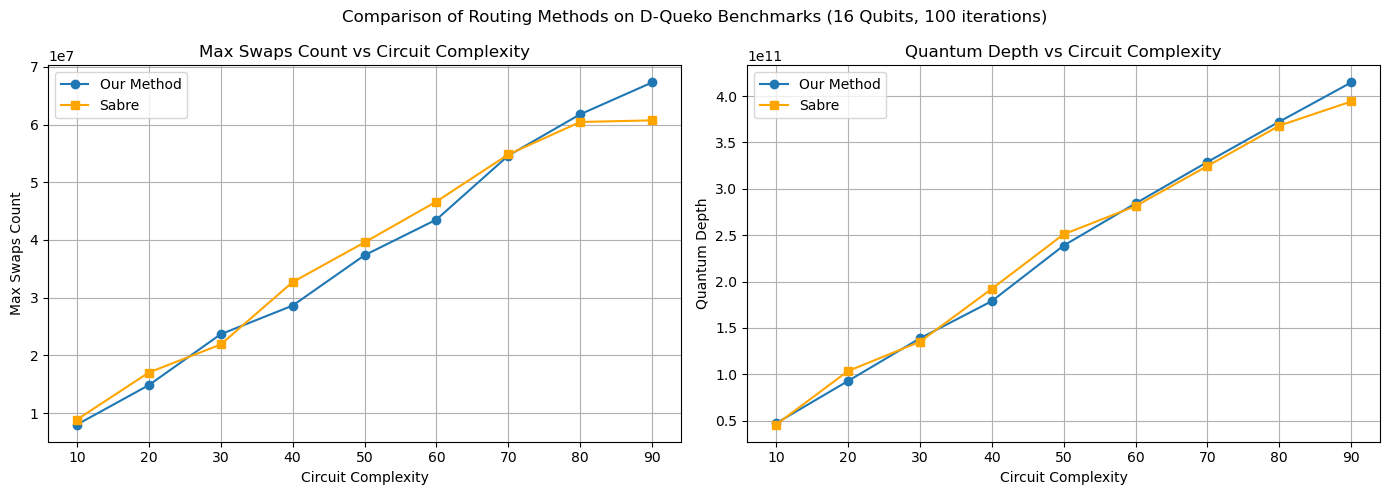

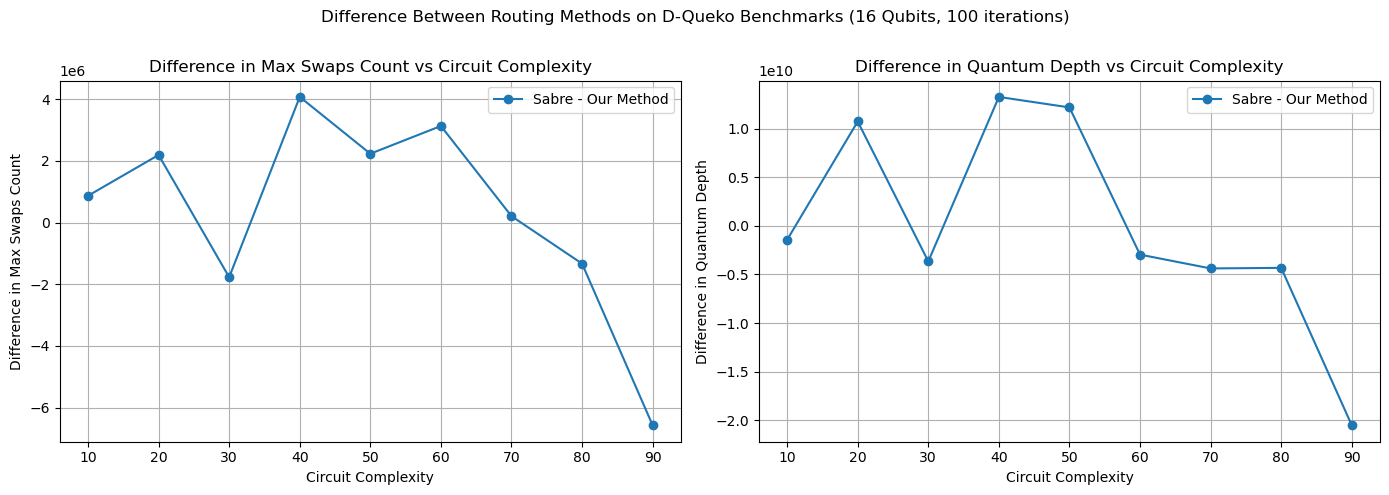

In [13]:
plot_routing_comparison(nb_qubits=16, nb_loop_iterations=100)

#### NB Qubits = 54, NB Loop Iterations = 100

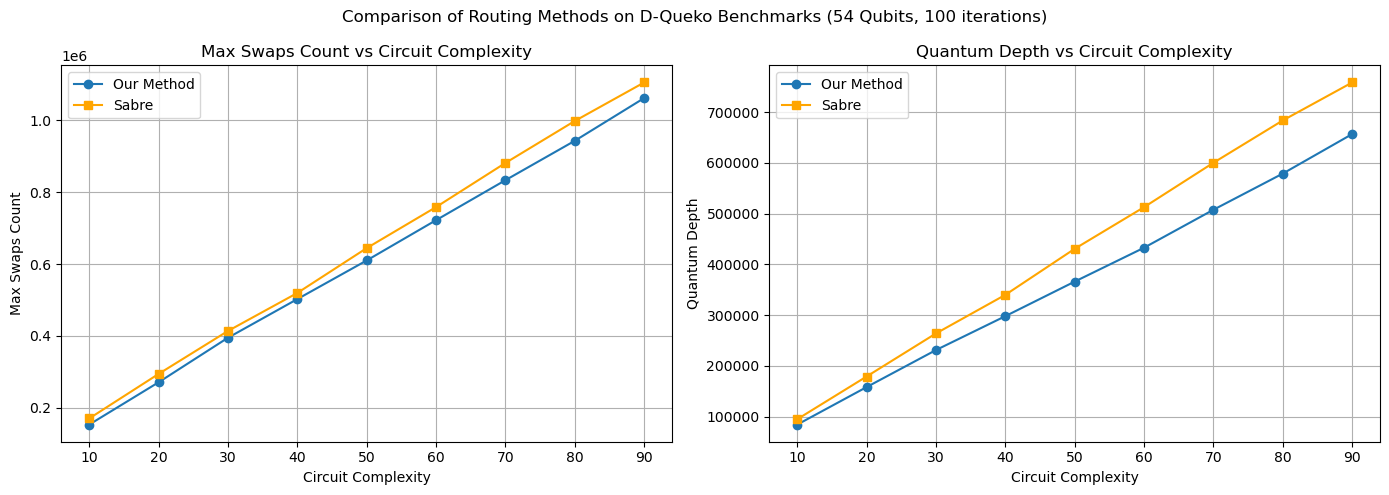

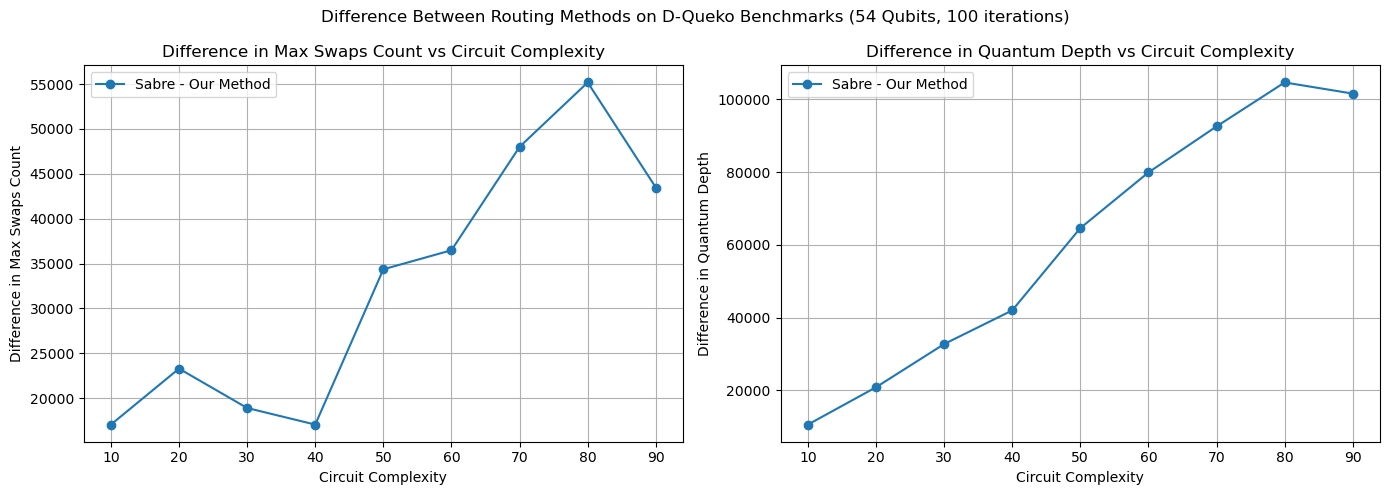

In [98]:
plot_routing_comparison(nb_qubits=54, nb_loop_iterations=100)

#### NB Qubits = 16, NB Loop Iterations = 200

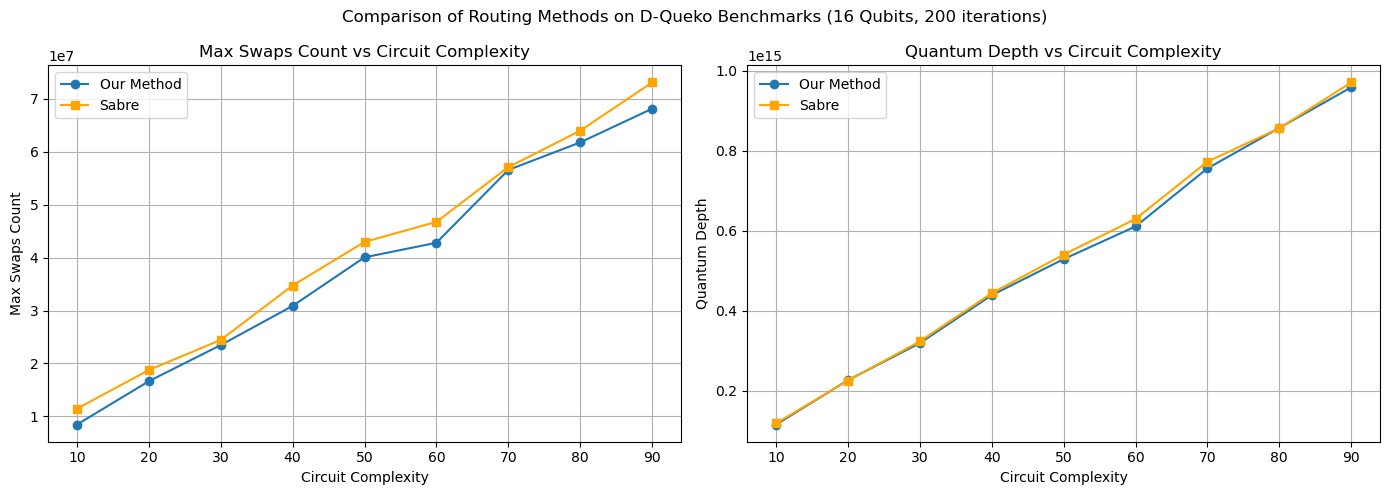

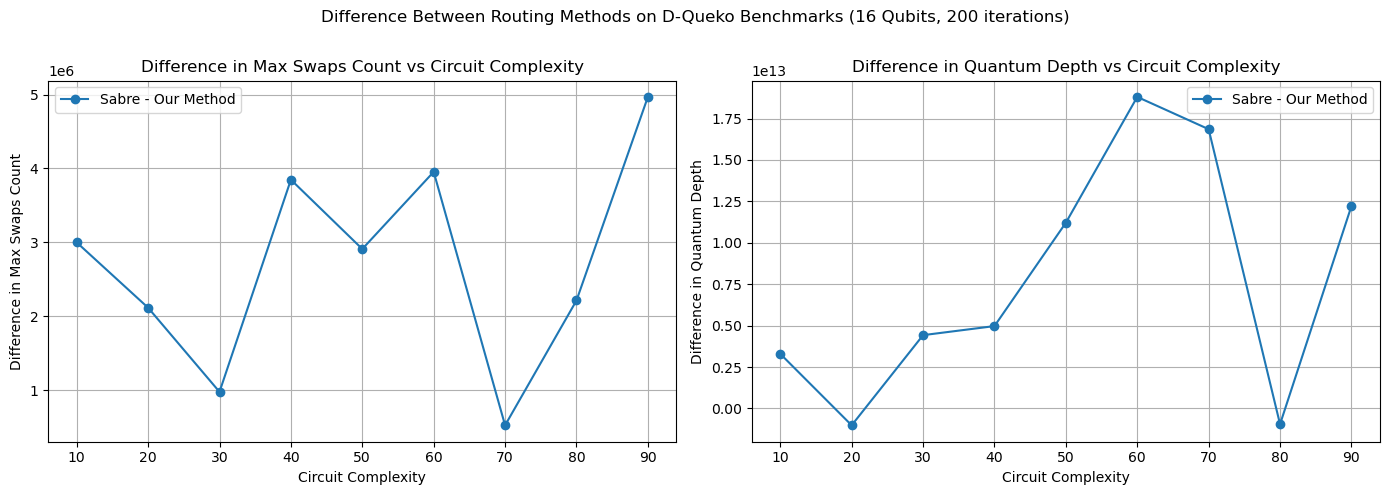

In [99]:
plot_routing_comparison(nb_qubits=16, nb_loop_iterations=200)

#### NB Qubits = 54, NB Loop Iterations = 200

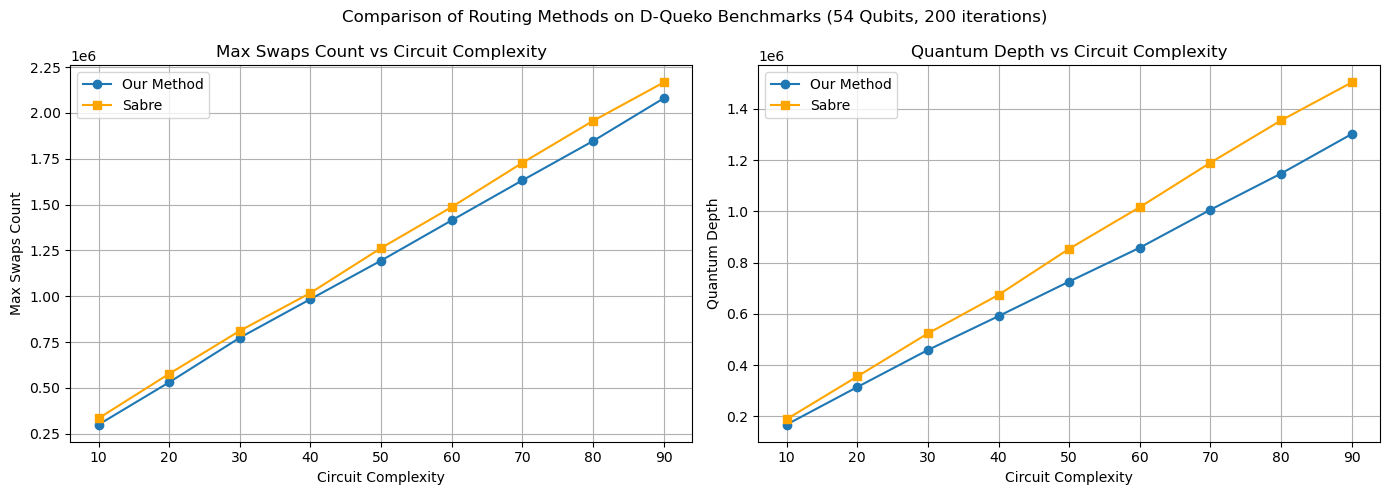

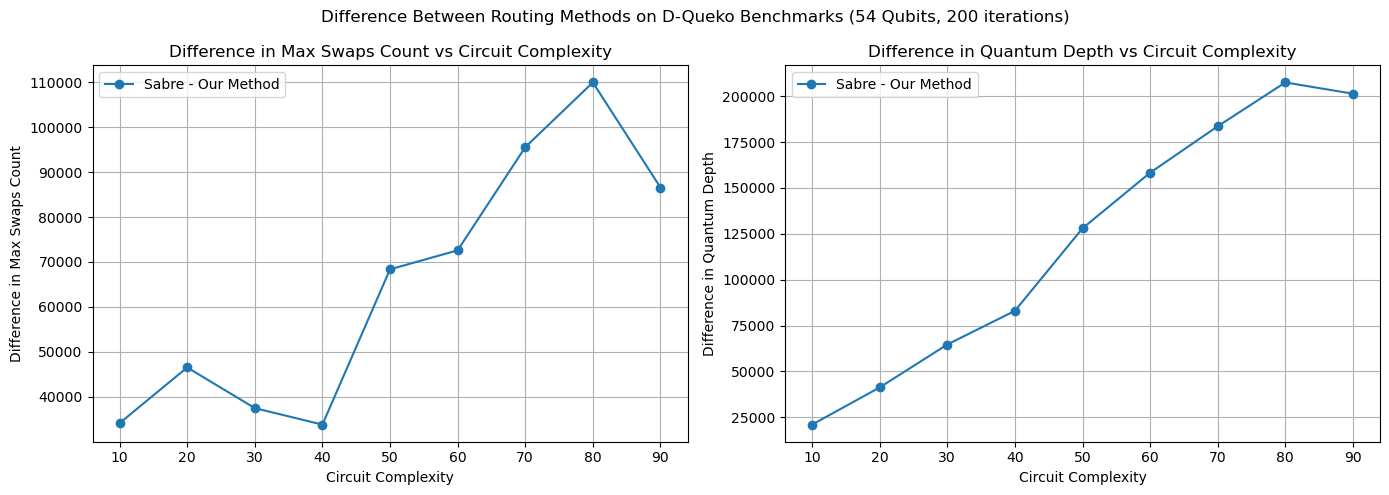

In [100]:
plot_routing_comparison(nb_qubits=54, nb_loop_iterations=200)

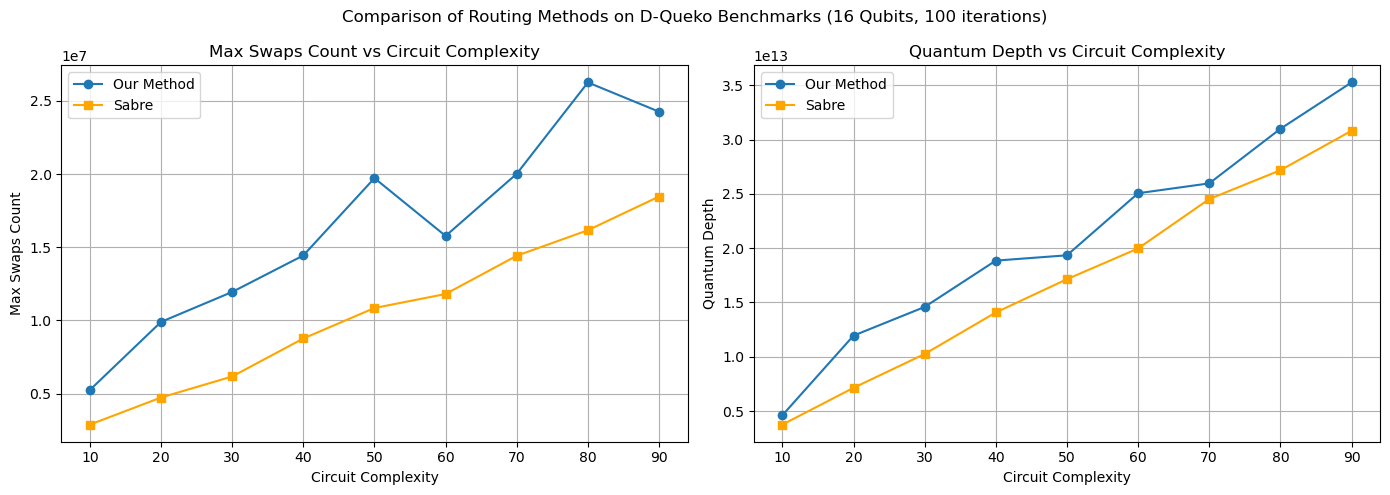

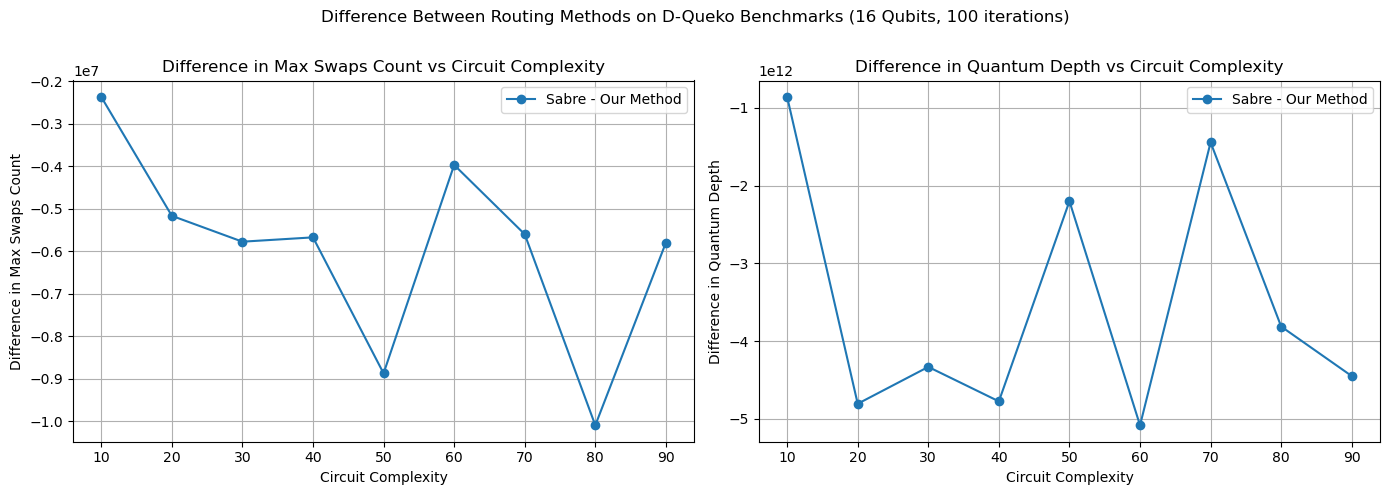

In [103]:

nb_qubits = 16
use_log_scale = False
nb_loop_iterations = 100
# Load files from results directories
results_dir = f'results/17qbt'
sabre_dir = f'results_sabre/{nb_qubits}qbt'

files = []
for root, dirs, filenames in os.walk(results_dir):
    for f in filenames:
        if f.endswith('.json'):
            files.append(os.path.join(root, f))

sabre_files = []
for root, dirs, filenames in os.walk(sabre_dir):
    for f in filenames:
        if f.endswith('.json'):
            sabre_files.append(os.path.join(root, f))

max_swaps = []
quantum_depths = []
file_names = []

max_swaps_sabre = []
quantum_depths_sabre = []
file_names_sabre = []

# Process each file
for file in files:
    with open(file, 'r') as fp:
        trace = json.load(fp)

    swaps = compute_max_swaps_count(
        trace, loop_iterations=nb_loop_iterations)
    if use_log_scale:
        swaps = 0 if swaps == 0 else round(np.log2(swaps))
    depth = compute_quantum_depth(
        trace, loop_iterations=nb_loop_iterations)
    if use_log_scale:
        depth = 0 if depth == 0 else round(np.log2(depth))

    max_swaps.append(swaps)
    quantum_depths.append(depth)
    file_names.append(file)

for file in sabre_files:
    with open(file, 'r') as fp:
        trace = json.load(fp)

    swaps = compute_max_swaps_count(
        trace, loop_iterations=nb_loop_iterations)
    if use_log_scale:
        swaps = 0 if swaps == 0 else round(np.log2(swaps))
    depth = compute_quantum_depth(
        trace, loop_iterations=nb_loop_iterations)
    if use_log_scale:
        depth = 0 if depth == 0 else round(np.log2(depth))

    max_swaps_sabre.append(swaps)
    quantum_depths_sabre.append(depth)
    file_names_sabre.append(file)

# Group files by their parent directory (leaf-depth level)
leaf_depth_groups = {}
leaf_depth_groups_sabre = {}

for i, file in enumerate(file_names):
    parts = file.split(os.sep)
    for part in parts:
        if 'leaf-depth-' in part:
            leaf_depth = int(part.split('leaf-depth-')[-1])
            if leaf_depth not in leaf_depth_groups:
                leaf_depth_groups[leaf_depth] = {'swaps': [], 'depths': []}
            leaf_depth_groups[leaf_depth]['swaps'].append(max_swaps[i])
            leaf_depth_groups[leaf_depth]['depths'].append(
                quantum_depths[i])
            break

for i, file in enumerate(file_names_sabre):
    parts = file.split(os.sep)
    for part in parts:
        if 'leaf-depth-' in part:
            leaf_depth = int(part.split('leaf-depth-')[-1])
            if leaf_depth not in leaf_depth_groups_sabre:
                leaf_depth_groups_sabre[leaf_depth] = {
                    'swaps': [], 'depths': []}
            leaf_depth_groups_sabre[leaf_depth]['swaps'].append(
                max_swaps_sabre[i])
            leaf_depth_groups_sabre[leaf_depth]['depths'].append(
                quantum_depths_sabre[i])
            break

# Calculate averages
leaf_depths_sorted = sorted(leaf_depth_groups.keys())
avg_swaps = [np.mean(leaf_depth_groups[ld]['swaps'])
                for ld in leaf_depths_sorted]
avg_depths = [np.mean(leaf_depth_groups[ld]['depths'])
                for ld in leaf_depths_sorted]

leaf_depths_sorted_sabre = sorted(leaf_depth_groups_sabre.keys())
avg_swaps_sabre = [np.mean(leaf_depth_groups_sabre[ld]['swaps'])
                    for ld in leaf_depths_sorted_sabre]
avg_depths_sabre = [np.mean(leaf_depth_groups_sabre[ld]['depths'])
                    for ld in leaf_depths_sorted_sabre]

# Plot the results
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(leaf_depths_sorted, avg_swaps, marker='o', label='Our Method')
ax1.plot(leaf_depths_sorted_sabre, avg_swaps_sabre,
            marker='s', color='orange', label='Sabre')
ax1.set_xlabel('Circuit Complexity')
ax1.set_ylabel('Max Swaps Count')
ax1.set_title('Max Swaps Count vs Circuit Complexity')
ax1.legend()
ax1.grid(True)

ax2.plot(leaf_depths_sorted, avg_depths, marker='o', label='Our Method')
ax2.plot(leaf_depths_sorted_sabre, avg_depths_sabre,
            marker='s', color='orange', label='Sabre')
ax2.set_xlabel('Circuit Complexity')
ax2.set_ylabel('Quantum Depth')
ax2.set_title('Quantum Depth vs Circuit Complexity')
ax2.legend()
ax2.grid(True)

fig.suptitle(
    f'Comparison of Routing Methods on D-Queko Benchmarks ({nb_qubits} Qubits, {nb_loop_iterations} iterations)')
plt.tight_layout()
plt.show()

# Plot difference between both methods
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

min_ld = min(len(leaf_depths_sorted), len(leaf_depths_sorted_sabre))
ax1.plot(leaf_depths_sorted[:min_ld], np.array(avg_swaps_sabre[:min_ld]) - np.array(avg_swaps[:min_ld]),
            marker='o', label='Sabre - Our Method')
ax1.set_xlabel('Circuit Complexity')
ax1.set_ylabel('Difference in Max Swaps Count')
ax1.set_title('Difference in Max Swaps Count vs Circuit Complexity')
ax1.legend()
ax1.grid(True)

ax2.plot(leaf_depths_sorted[:min_ld], np.array(avg_depths_sabre[:min_ld]) - np.array(avg_depths[:min_ld]),
            marker='o', label='Sabre - Our Method')
ax2.set_xlabel('Circuit Complexity')
ax2.set_ylabel('Difference in Quantum Depth')
ax2.set_title('Difference in Quantum Depth vs Circuit Complexity')
ax2.legend()
ax2.grid(True)

fig.suptitle(
    f'Difference Between Routing Methods on D-Queko Benchmarks ({nb_qubits} Qubits, {nb_loop_iterations} iterations)')
plt.tight_layout()
plt.show()